### Analysis of Factors Predicting User Adoption

Objective

The goal of this analysis is to identify which factors predict whether a user will adopt the product. Adoption is defined according to the product team’s criteria, and features were computed using user activity, account creation metadata, and engagement flags.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

#### Read data files

In [2]:
users = pd.read_csv('../takehome_users.csv', encoding="ISO-8859-1")
engagements = pd.read_csv('../takehome_user_engagement.csv', encoding="ISO-8859-1")

In [3]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [4]:
engagements.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [5]:
# Extract date from login timestamps
# timestamp -> login date
engagements['time_stamp'] = pd.to_datetime(engagements['time_stamp'])
engagements['login_date'] = pd.to_datetime(engagements['time_stamp'].dt.date)

In [6]:
engagements.head()

,time_stamp,user_id,visited,login_date
0,2014-04-22 03:53:30,1,1,2014-04-22
1,2013-11-15 03:45:04,2,1,2013-11-15
2,2013-11-29 03:45:04,2,1,2013-11-29
3,2013-12-09 03:45:04,2,1,2013-12-09
4,2013-12-25 03:45:04,2,1,2013-12-25


In [7]:
# Get creation time
# creation time from 'users'
engagement_sessions = engagements.merge(users[['object_id', 'creation_time']], left_on='user_id', right_on='object_id', how='left')

# Normalize creation date and login date
# creation_time -> creation_date
engagement_sessions['creation_date'] = pd.to_datetime(engagement_sessions['creation_time']).dt.normalize()
engagement_sessions['login_date'] = engagement_sessions['login_date'].dt.normalize()
engagement_sessions.drop(columns=['visited', 'object_id', 'creation_time'], inplace=True)

In [8]:
# days since user created
full_sessions = engagement_sessions.copy()
full_sessions['days_since_creation'] = (full_sessions['login_date'] - full_sessions['creation_date']).dt.days
full_sessions.head(20)

,time_stamp,user_id,login_date,creation_date,days_since_creation
0,2014-04-22 03:53:30,1,2014-04-22,2014-04-22,0
1,2013-11-15 03:45:04,2,2013-11-15,2013-11-15,0
2,2013-11-29 03:45:04,2,2013-11-29,2013-11-15,14
3,2013-12-09 03:45:04,2,2013-12-09,2013-11-15,24
4,2013-12-25 03:45:04,2,2013-12-25,2013-11-15,40
5,2013-12-31 03:45:04,2,2013-12-31,2013-11-15,46
6,2014-01-08 03:45:04,2,2014-01-08,2013-11-15,54
7,2014-02-03 03:45:04,2,2014-02-03,2013-11-15,80
8,2014-02-08 03:45:04,2,2014-02-08,2013-11-15,85
9,2014-02-09 03:45:04,2,2014-02-09,2013-11-15,86


#### Target leakage
To avoid leakage in feature engineering, first 14 days counts should be pre-adoption for adopted users

In [9]:
# only need one session per day per user
# each user -> one login day count
user_sessions = full_sessions.drop_duplicates(['user_id', 'login_date'])
user_sessions = user_sessions.sort_values(['user_id', 'login_date'])
user_sessions.head(10)

,time_stamp,user_id,login_date,creation_date,days_since_creation
0,2014-04-22 03:53:30,1,2014-04-22,2014-04-22,0
1,2013-11-15 03:45:04,2,2013-11-15,2013-11-15,0
2,2013-11-29 03:45:04,2,2013-11-29,2013-11-15,14
3,2013-12-09 03:45:04,2,2013-12-09,2013-11-15,24
4,2013-12-25 03:45:04,2,2013-12-25,2013-11-15,40
5,2013-12-31 03:45:04,2,2013-12-31,2013-11-15,46
6,2014-01-08 03:45:04,2,2014-01-08,2013-11-15,54
7,2014-02-03 03:45:04,2,2014-02-03,2013-11-15,80
8,2014-02-08 03:45:04,2,2014-02-08,2013-11-15,85
9,2014-02-09 03:45:04,2,2014-02-09,2013-11-15,86


In [10]:
# Find start of current window date - 2 logins back
# user login date -> window start, two logins before
user_sessions['window_start_date'] = user_sessions.groupby('user_id').login_date.shift(2)
user_sessions.head(10)

,time_stamp,user_id,login_date,creation_date,days_since_creation,window_start_date
0,2014-04-22 03:53:30,1,2014-04-22,2014-04-22,0,NaT
1,2013-11-15 03:45:04,2,2013-11-15,2013-11-15,0,NaT
2,2013-11-29 03:45:04,2,2013-11-29,2013-11-15,14,NaT
3,2013-12-09 03:45:04,2,2013-12-09,2013-11-15,24,2013-11-15
4,2013-12-25 03:45:04,2,2013-12-25,2013-11-15,40,2013-11-29
5,2013-12-31 03:45:04,2,2013-12-31,2013-11-15,46,2013-12-09
6,2014-01-08 03:45:04,2,2014-01-08,2013-11-15,54,2013-12-25
7,2014-02-03 03:45:04,2,2014-02-03,2013-11-15,80,2013-12-31
8,2014-02-08 03:45:04,2,2014-02-08,2013-11-15,85,2014-01-08
9,2014-02-09 03:45:04,2,2014-02-09,2013-11-15,86,2014-02-03


In [11]:
# Days occupying window (adoption criteria, must be < 7)
# days between window_start_date and login_date
user_sessions['days_in_window'] = (user_sessions['login_date'] - user_sessions['window_start_date']).dt.days
user_sessions.shape

(207917, 7)

In [12]:
# Mark users adopted if window occupies less than or equal to 6 days
# Identify users who reached adoption
# if number of days in window <= 6, adopted
adopted_users = user_sessions[user_sessions['days_in_window'] <= 6]['user_id'].unique()

# Filter only adopted users
# adopted users login sessions per day
adopted_user_sessions = user_sessions[user_sessions['user_id'].isin(adopted_users)].copy()

# For each adopted user, find the first window where days_in_window <= 6
# first qualifying adopted window, use login_date as adoption_cutoff_date
adoption_cutoff = (adopted_user_sessions[adopted_user_sessions['days_in_window'] <= 6].groupby('user_id')['login_date'].first()
    .rename('adoption_cutoff_date')
    .reset_index()
)

# Merge cutoff back to all sessions (so non-adopted users will have NaT)
sessions_with_cutoff = full_sessions.merge(adoption_cutoff, on='user_id', how='left')
sessions_with_cutoff.head(10)

,time_stamp,user_id,login_date,creation_date,days_since_creation,adoption_cutoff_date
0,2014-04-22 03:53:30,1,2014-04-22,2014-04-22,0,NaT
1,2013-11-15 03:45:04,2,2013-11-15,2013-11-15,0,2014-02-09
2,2013-11-29 03:45:04,2,2013-11-29,2013-11-15,14,2014-02-09
3,2013-12-09 03:45:04,2,2013-12-09,2013-11-15,24,2014-02-09
4,2013-12-25 03:45:04,2,2013-12-25,2013-11-15,40,2014-02-09
5,2013-12-31 03:45:04,2,2013-12-31,2013-11-15,46,2014-02-09
6,2014-01-08 03:45:04,2,2014-01-08,2013-11-15,54,2014-02-09
7,2014-02-03 03:45:04,2,2014-02-03,2013-11-15,80,2014-02-09
8,2014-02-08 03:45:04,2,2014-02-08,2013-11-15,85,2014-02-09
9,2014-02-09 03:45:04,2,2014-02-09,2013-11-15,86,2014-02-09


In [13]:
# Keep sessions only before adoption cutoff for adopted users
# session up until adoption_cutoff_date
sessions_with_cutoff = sessions_with_cutoff[(sessions_with_cutoff['adoption_cutoff_date'].isna()) | 
                                                       (sessions_with_cutoff['login_date'] <= sessions_with_cutoff['adoption_cutoff_date'])]
sessions_with_cutoff.head(20)

,time_stamp,user_id,login_date,creation_date,days_since_creation,adoption_cutoff_date
0,2014-04-22 03:53:30,1,2014-04-22,2014-04-22,0,NaT
1,2013-11-15 03:45:04,2,2013-11-15,2013-11-15,0,2014-02-09
2,2013-11-29 03:45:04,2,2013-11-29,2013-11-15,14,2014-02-09
3,2013-12-09 03:45:04,2,2013-12-09,2013-11-15,24,2014-02-09
4,2013-12-25 03:45:04,2,2013-12-25,2013-11-15,40,2014-02-09
5,2013-12-31 03:45:04,2,2013-12-31,2013-11-15,46,2014-02-09
6,2014-01-08 03:45:04,2,2014-01-08,2013-11-15,54,2014-02-09
7,2014-02-03 03:45:04,2,2014-02-03,2013-11-15,80,2014-02-09
8,2014-02-08 03:45:04,2,2014-02-08,2013-11-15,85,2014-02-09
9,2014-02-09 03:45:04,2,2014-02-09,2013-11-15,86,2014-02-09


In [14]:
(sessions_with_cutoff['login_date'] > sessions_with_cutoff['adoption_cutoff_date']).sum()

np.int64(0)

### Aggregate features

In [15]:
# sessions in the first 14 days
first_14_days_sessions = sessions_with_cutoff[sessions_with_cutoff['days_since_creation'] < 14]

- active_days_first_14_days: Measures early engagement consistency

In [16]:
# Active days in first 14 days
# unique days per user in first 14 days
active_days_first_14 = first_14_days_sessions.groupby('user_id')['login_date'].nunique().rename('active_days_first_14_days').reset_index()
active_days_first_14.head(15)

,user_id,active_days_first_14_days
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
5,6,1
6,7,1
7,10,2
8,11,1
9,13,1


- days_active_before_adoption: number of days before adoption

In [17]:
# Count unique days per user
days_active_before_adoption = sessions_with_cutoff.groupby('user_id')['login_date'].nunique().rename('days_active_before_adoption').reset_index()
days_active_before_adoption.head(15)

,user_id,days_active_before_adoption
0,1,1
1,2,9
2,3,1
3,4,1
4,5,1
5,6,1
6,7,1
7,10,8
8,11,1
9,13,1


- days_since_creation_before_adoption: maximum days_since_creation before adoption cutoff

In [18]:
days_since_creation_before_adoption = sessions_with_cutoff.groupby('user_id')['days_since_creation'].max()\
                                                          .rename('days_since_creation_before_adoption').reset_index()

days_since_creation_before_adoption.head(15)

,user_id,days_since_creation_before_adoption
0,1,0
1,2,86
2,3,0
3,4,1
4,5,5
5,6,2
6,7,4
7,10,34
8,11,1
9,13,0


### Target label
Calculated adopted users above, I just add flag if they are adopted

In [19]:
# Create a user-level DataFrame with adopted flag
adopted_flag_df = pd.DataFrame({'user_id': user_sessions['user_id'].unique()})
adopted_flag_df['adopted'] = adopted_flag_df['user_id'].isin(adopted_users).astype(int)

# Time-to-adoption summary for adopted users
time_to_adopt_summary = days_since_creation_before_adoption[days_since_creation_before_adoption['user_id'].isin(adopted_users)]['days_since_creation_before_adoption']

print("Time-to-adoption")
print(f"Min: {time_to_adopt_summary.min():.0f}")
print(f"Max: {time_to_adopt_summary.max():.0f}")
print(f"Median: {time_to_adopt_summary.median():.0f}")
print(f"Mean: {time_to_adopt_summary.mean():.0f}")

adopted_flag_df.head()

Time-to-adoption
Min: 2
Max: 303
Median: 48
Mean: 54


,user_id,adopted
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


### Retrieve any info from users df

In [20]:
users.columns

Index(['object_id', 'creation_time', 'name', 'email', 'creation_source',
       'last_session_creation_time', 'opted_in_to_mailing_list',
       'enabled_for_marketing_drip', 'org_id', 'invited_by_user_id'],
      dtype='object')

#### One-hot encode creation_source

In [21]:
users_df = users.copy()
users_df.creation_source.value_counts()

creation_source
ORG_INVITE            4254
GUEST_INVITE          2163
PERSONAL_PROJECTS     2111
SIGNUP                2087
SIGNUP_GOOGLE_AUTH    1385
Name: count, dtype: int64

In [22]:
user_creation_source_df = users_df[['object_id', 'creation_source']].copy()
user_creation_source_df.rename(columns={'object_id': 'user_id'}, inplace=True)

In [23]:
creation_dummies = pd.get_dummies(user_creation_source_df['creation_source'], prefix='creation', drop_first=True).astype(int)
user_creation_dummies_df = pd.concat([user_creation_source_df[['user_id']], creation_dummies], axis=1)
user_creation_dummies_df.head()

,user_id,creation_ORG_INVITE,creation_PERSONAL_PROJECTS,creation_SIGNUP,creation_SIGNUP_GOOGLE_AUTH
0,1,0,0,0,0
1,2,1,0,0,0
2,3,1,0,0,0
3,4,0,0,0,0
4,5,0,0,0,0


#### Part of an organization flag creation

In [24]:
user_org_flag = users_df[['object_id', 'org_id']].copy()
user_org_flag.rename(columns={'object_id': 'user_id'}, inplace=True)

# Binary flag: 1 if org_id not equal to 0, 0 if 0
user_org_flag['part_of_org'] = (user_org_flag['org_id'] != 0).astype(int)

# Keep only user_id and flag
user_org_flag = user_org_flag[['user_id', 'part_of_org']]
user_org_flag.head()

,user_id,part_of_org
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [25]:
user_org_flag['part_of_org'].value_counts(normalize=True)

part_of_org
1    0.973417
0    0.026583
Name: proportion, dtype: float64

#### Invited by user?

In [26]:
user_invited_by_user_flag = users_df[['object_id', 'invited_by_user_id']].copy()
user_invited_by_user_flag.rename(columns={'object_id': 'user_id'}, inplace=True)

# Binary flag: 1 if invited_by_user_id exists, 0 if NaN
user_invited_by_user_flag['was_invited'] = user_invited_by_user_flag['invited_by_user_id'].notna().astype(int)

# Keep only user_id and flag
user_invited_by_user_flag = user_invited_by_user_flag[['user_id', 'was_invited']]
user_invited_by_user_flag.head()

,user_id,was_invited
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [27]:
user_invited_by_user_flag['was_invited'].value_counts(normalize=True)

was_invited
1    0.53475
0    0.46525
Name: proportion, dtype: float64

#### Other

In [28]:
other_user_features = ['object_id', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip']
other_user_cols = users_df[other_user_features].copy()
other_user_cols.rename(columns={'object_id': 'user_id'}, inplace=True)
other_user_cols.head()

,user_id,opted_in_to_mailing_list,enabled_for_marketing_drip
0,1,1,0
1,2,0,0
2,3,0,0
3,4,0,0
4,5,0,0


#### Putting it all together

In [29]:
print("User engagement features\n")
print(active_days_first_14.shape)
print(days_active_before_adoption.shape)
print(days_since_creation_before_adoption.shape)

print("Target feature\n")
print(adopted_flag_df.shape)

print("User info features\n")
print(user_creation_dummies_df.shape)
print(user_org_flag.shape)
print(user_invited_by_user_flag.shape)
print(other_user_cols.shape)

User engagement features

(8822, 2)
(8823, 2)
(8823, 2)
Target feature

(8823, 2)
User info features

(12000, 5)
(12000, 2)
(12000, 2)
(12000, 3)


#### Users with no login sessions
I will impute engagement features with 0 and adopted as 0 for users without any login info

In [30]:
modeling_df = pd.DataFrame({'user_id': users_df['object_id']})

modeling_df = modeling_df.merge(active_days_first_14, on='user_id', how='left')
modeling_df = modeling_df.merge(days_active_before_adoption, on='user_id', how='left')
modeling_df = modeling_df.merge(days_since_creation_before_adoption, on='user_id', how='left')

modeling_df = modeling_df.merge(user_creation_dummies_df, on='user_id', how='left')
modeling_df = modeling_df.merge(user_org_flag, on='user_id', how='left')
modeling_df = modeling_df.merge(user_invited_by_user_flag, on='user_id', how='left')
modeling_df = modeling_df.merge(other_user_cols, on='user_id', how='left')

modeling_df = modeling_df.merge(adopted_flag_df, on='user_id', how='left')

modeling_df.isna().sum()

user_id                                   0
active_days_first_14_days              3178
days_active_before_adoption            3177
days_since_creation_before_adoption    3177
creation_ORG_INVITE                       0
creation_PERSONAL_PROJECTS                0
creation_SIGNUP                           0
creation_SIGNUP_GOOGLE_AUTH               0
part_of_org                               0
was_invited                               0
opted_in_to_mailing_list                  0
enabled_for_marketing_drip                0
adopted                                3177
dtype: int64

In [31]:
# Impute with 0 for missing users
modeling_df['active_days_first_14_days'] = modeling_df['active_days_first_14_days'].fillna(0).astype(int)

# other missing
missing = ['days_active_before_adoption', 'days_since_creation_before_adoption', 'adopted']
modeling_df[missing] = modeling_df[missing].fillna(0).astype(int)
modeling_df.isna().sum()

user_id                                0
active_days_first_14_days              0
days_active_before_adoption            0
days_since_creation_before_adoption    0
creation_ORG_INVITE                    0
creation_PERSONAL_PROJECTS             0
creation_SIGNUP                        0
creation_SIGNUP_GOOGLE_AUTH            0
part_of_org                            0
was_invited                            0
opted_in_to_mailing_list               0
enabled_for_marketing_drip             0
adopted                                0
dtype: int64

In [32]:
# Adopted percentages
modeling_df.adopted.value_counts(normalize=True)

adopted
0    0.8665
1    0.1335
Name: proportion, dtype: float64

### Data and Features Considered

#### User Engagement Features

- days_active_before_adoption: Total number of days the user was active before adoption (or last session for non-adopters).

- days_since_creation_before_adoption: Time from account creation to adoption (or last session for non-adopters).

#### User Info / Metadata Flags

- Creation source (e.g., ORG_INVITE, PERSONAL_PROJECTS, SIGNUP, SIGNUP_GOOGLE_AUTH).

- Marketing flags (enabled_for_marketing_drip, opted_in_to_mailing_list).

- Invitation status (was_invited).

Note: Features like sessions_first_14_days were initially considered but dropped to avoid redundancy. I preferred to only keep 'days_active_before_adoption' which is the same as 'sessions_first_14_days'(no multiple logins per day).

#### Methodology

Data was aggregated at the user level, with features limited to activity up to the adoption date to prevent leakage. Logistic regression was chosen for interpretability, and feature coefficients were used to assess predictive strength.

### Modelling

In [33]:
# Check adoption rate by part_of_org — significant difference, keeping feature
modeling_df.groupby('part_of_org')['adopted'].mean()

part_of_org
0    0.034483
1    0.136204
Name: adopted, dtype: float64

In [34]:
# Set user_id as index for modeling
if 'user_id' in modeling_df.columns:
    modeling_df = modeling_df.set_index('user_id')

# Target
y = modeling_df['adopted']

# Build feature matrix in one block to avoid state issues on re-run
X = modeling_df.drop(columns='adopted')
X['log_days_active_before_adoption'] = np.log1p(X['days_active_before_adoption'])
X['log_days_since_creation_before_adoption'] = np.log1p(X['days_since_creation_before_adoption'])
X = X.drop(columns=['days_active_before_adoption', 'days_since_creation_before_adoption', 'active_days_first_14_days'])
X.head()

,creation_ORG_INVITE,creation_PERSONAL_PROJECTS,creation_SIGNUP,creation_SIGNUP_GOOGLE_AUTH,part_of_org,was_invited,opted_in_to_mailing_list,enabled_for_marketing_drip,log_days_active_before_adoption,log_days_since_creation_before_adoption
user_id,,,,,,,,,,
1,0,0,0,0,1,1,1,0,0.693147,0.000000
2,1,0,0,0,1,1,0,0,2.302585,4.465908
3,1,0,0,0,1,1,0,0,0.693147,0.000000
4,0,0,0,0,1,1,0,0,0.693147,0.693147
5,0,0,0,0,1,1,0,0,0.693147,1.791759


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
# Logistic Regression pipeline
# Only scale continuous features; pass binary features through unchanged for interpretability
numeric_features = ['log_days_active_before_adoption', 'log_days_since_creation_before_adoption']
binary_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features)
])

# highly imbalanced target
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('log_reg', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

In [37]:
# Fit model
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc}")

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      2080
           1       0.79      1.00      0.88       320

    accuracy                           0.96      2400
   macro avg       0.89      0.98      0.93      2400
weighted avg       0.97      0.96      0.97      2400

ROC-AUC: 0.9871612079326924


/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/safarifgisa/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow 

In [38]:
# Get coefficients from the trained logistic regression
coef = pipe.named_steps['log_reg'].coef_[0]

# ColumnTransformer outputs numeric features first, then binary features
feature_names = numeric_features + binary_features

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
})

# Sort by absolute value to see most predictive features
feature_importance['abs_coeff'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coeff', ascending=False)

print(feature_importance[['feature', 'coefficient']])

                                   feature  coefficient
0          log_days_active_before_adoption     6.899676
1  log_days_since_creation_before_adoption    -2.033562
6                              part_of_org     0.679988
9               enabled_for_marketing_drip    -0.305579
2                      creation_ORG_INVITE    -0.153316
8                 opted_in_to_mailing_list     0.147549
3               creation_PERSONAL_PROJECTS    -0.121210
7                              was_invited     0.026355
5              creation_SIGNUP_GOOGLE_AUTH    -0.014383
4                          creation_SIGNUP     0.001013


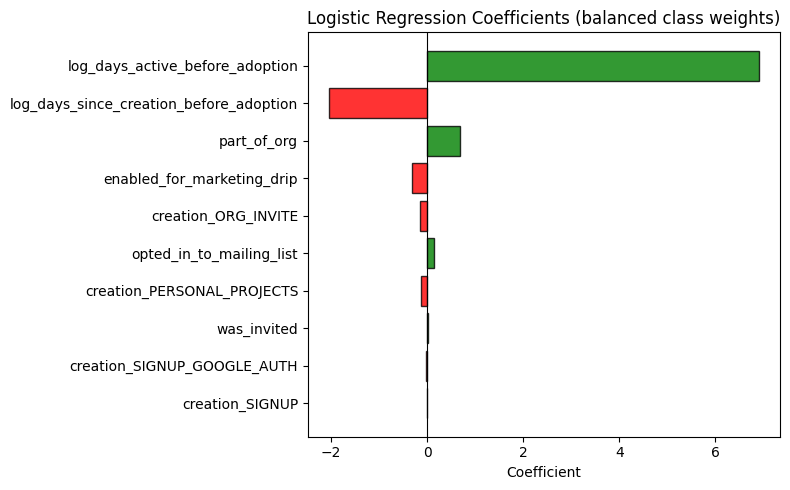

In [39]:
# Coefficient bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in feature_importance['coefficient']]
ax.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression Coefficients (balanced class weights)')
ax.axvline(0, color='black', linewidth=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Observations
- Users who are more active early in their account’s life are far more likely to adopt the product.
- The longer it takes a user to adopt after signing up, the less likely they are to do so.
- Other factors, like how the user signed up, whether they were invited, or marketing indicators, have very little impact compared to early activity.

Early engagement is the strongest predictor of future adoption.

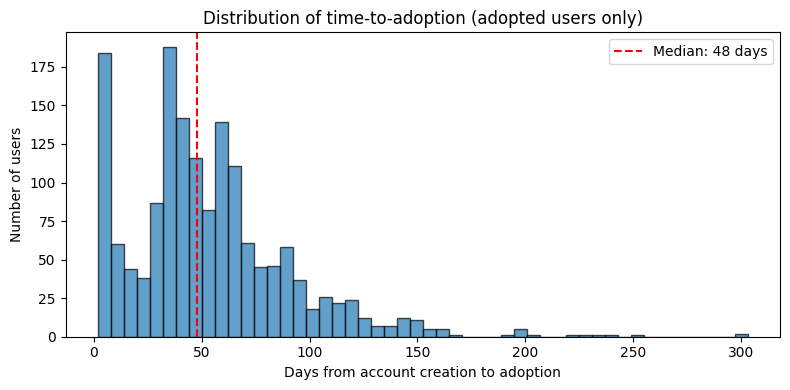

In [40]:
adopted_ids = set(adopted_flag_df.loc[adopted_flag_df['adopted'] == 1, 'user_id'])
time_to_adopt = days_since_creation_before_adoption.loc[
    days_since_creation_before_adoption['user_id'].isin(adopted_ids), 'days_since_creation_before_adoption'
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(time_to_adopt, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Days from account creation to adoption')
ax.set_ylabel('Number of users')
ax.set_title('Distribution of time-to-adoption (adopted users only)')
ax.axvline(time_to_adopt.median(), color='red', linestyle='--', label=f'Median: {time_to_adopt.median():.0f} days')
ax.legend()
plt.tight_layout()
plt.show()

#### Further Considerations

- Adoption timing patterns
  
Explore whether users adopt in bursts of activity versus steady engagement. For example, do a few highly active days early predict adoption more than many low-activity days?

- Cross-feature interactions

Investigate whether certain combinations of flags and engagement metrics amplify adoption likelihood. For instance, does being invited and active in the first week increase adoption disproportionately?

- Adoption horizon

Adoption was defined relative to each user, resulting in inconsistent horizons. Using a standardized window across users could improve comparability and clarity of the analysis.


**Note:** Since adoption requires ≥ 3 logins, `days_active_before_adoption` has a built-in floor for adopters. This is fine for explanatory analysis but would need rethinking for prospective prediction.